# Day vs Night — Binary Image Classification with a CNN
**Dataset:** [Day-night Dataset (DNIM)](https://www.kaggle.com/datasets/stevemark/daynight-dataset) — ~1,722 images from 17 fixed webcam sequences.

**Pipeline:** Download from Kaggle → auto-inspect folder structure → build Day/Night labels from timestamps → preprocess & augment → CNN (sigmoid, binary_crossentropy) → train → evaluate → predict on your own image.



In [7]:
!pip install -q kaggle tensorflow scikit-learn seaborn matplotlib pandas numpy pillow
print("Libraries installed.")

Libraries installed.


In [8]:
import os, io, json, shutil, zipfile, random, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [9]:
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()  # upload kaggle.json here

os.makedirs('/root/.kaggle', exist_ok=True)
for fname in uploaded.keys():
    shutil.move(fname, '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials configured.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [10]:
DATASET_SLUG = "stevemark/daynight-dataset"
DATA_DIR = "/content/day_night_data"
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d {DATASET_SLUG} -p {DATA_DIR}
print("\nDownload complete. Files:")
!ls -la {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/stevemark/daynight-dataset
License(s): other
daynight-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

Download complete. Files:
total 115352
drwxr-xr-x 3 root root      4096 Sep 15 16:19 .
drwxr-xr-x 1 root root      4096 Sep 15 16:19 ..
-rw-r--r-- 1 root root 118105169 Apr 27  2021 daynight-dataset.zip
drwxr-xr-x 4 root root      4096 Sep 15 16:19 DNIM


In [11]:
zip_path = None
for f in os.listdir(DATA_DIR):
    if f.endswith(".zip"):
        zip_path = os.path.join(DATA_DIR, f)
        break

assert zip_path is not None, "No .zip file found — check the download step above."

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(DATA_DIR)

print("Extracted to:", DATA_DIR)

Extracted to: /content/day_night_data


In [12]:
def find_dirs(root, targets=("Image", "time_stamp")):
    found = {}
    for dirpath, dirnames, filenames in os.walk(root):
        base = os.path.basename(dirpath)
        if base in targets:
            found[base] = dirpath
    return found

located = find_dirs(DATA_DIR)
print("Located folders:", located)

assert "Image" in located and "time_stamp" in located, (
    "Could not auto-locate Image/ and time_stamp/ folders — "
    "print the tree below and adjust find_dirs() targets if Kaggle changed the layout."
)

IMAGE_ROOT = located["Image"]
TIMESTAMP_ROOT = located["time_stamp"]

sequence_ids = sorted(os.listdir(IMAGE_ROOT))
print(f"\nFound {len(sequence_ids)} sequences under {IMAGE_ROOT}")
print("Example sequences:", sequence_ids[:5])

total_images = sum(len(os.listdir(os.path.join(IMAGE_ROOT, s))) for s in sequence_ids)
print(f"Total images across all sequences: {total_images}")

Located folders: {'Image': '/content/day_night_data/DNIM/Image', 'time_stamp': '/content/day_night_data/DNIM/time_stamp'}

Found 17 sequences under /content/day_night_data/DNIM/Image
Example sequences: ['00000850', '00001323', '00003548', '00003837', '00004232']
Total images across all sequences: 1722


In [13]:
def band_from_time(hh, mm):
    minutes = hh * 60 + mm
    day_start = 7 * 60      # 07:00
    day_end   = 17 * 60 + 59  # 17:59
    return "Day" if day_start <= minutes <= day_end else "Night"

records = []
for seq_id in sequence_ids:
    ts_file = os.path.join(TIMESTAMP_ROOT, f"{seq_id}.txt")
    img_dir = os.path.join(IMAGE_ROOT, seq_id)
    if not os.path.exists(ts_file):
        continue
    with open(ts_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            fname, date_str, hh, mm = parts[0], parts[1], int(parts[2]), int(parts[3])
            img_path = os.path.join(img_dir, fname)
            if os.path.exists(img_path):
                records.append({
                    "filepath": img_path,
                    "sequence": seq_id,
                    "hour": hh,
                    "minute": mm,
                    "label": band_from_time(hh, mm)
                })

df = pd.DataFrame(records)
print("Total labeled images:", len(df))
print(df["label"].value_counts())
df.head()

Total labeled images: 1722
label
Night    936
Day      786
Name: count, dtype: int64


,filepath,sequence,hour,minute,label
0,/content/day_night_data/DNIM/Image/00000850/20...,00000850,0,27,Night
1,/content/day_night_data/DNIM/Image/00000850/20...,00000850,0,56,Night
2,/content/day_night_data/DNIM/Image/00000850/20...,00000850,1,26,Night
3,/content/day_night_data/DNIM/Image/00000850/20...,00000850,1,57,Night
4,/content/day_night_data/DNIM/Image/00000850/20...,00000850,2,27,Night


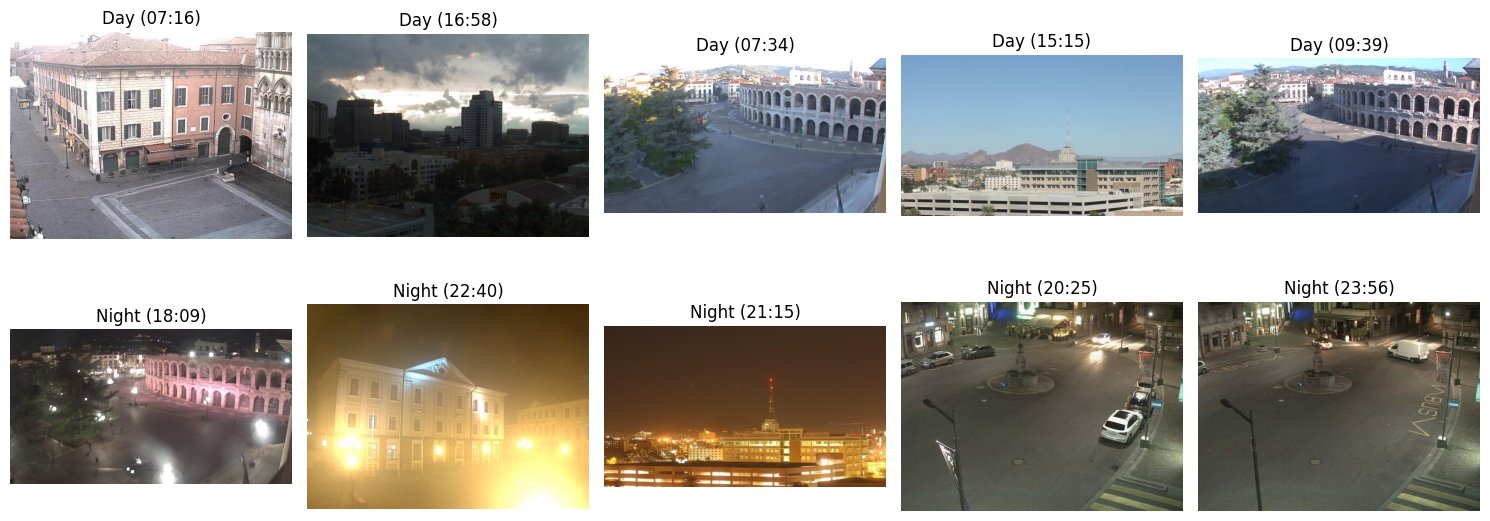

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(["Day", "Night"]):
    sample = df[df["label"] == cls].sample(5, random_state=SEED)
    for j, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row["filepath"])
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{cls} ({row["hour"]:02d}:{row["minute"]:02d})')
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), train_df["label"].value_counts().to_dict())
print("Val:  ", len(val_df),   val_df["label"].value_counts().to_dict())
print("Test: ", len(test_df),  test_df["label"].value_counts().to_dict())

Train: 1205 {'Night': 655, 'Day': 550}
Val:   258 {'Night': 140, 'Day': 118}
Test:  259 {'Night': 141, 'Day': 118}


In [16]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="binary",
    batch_size=BATCH_SIZE, shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 1205 validated image filenames belonging to 2 classes.
Found 258 validated image filenames belonging to 2 classes.
Found 259 validated image filenames belonging to 2 classes.
Class indices: {'Day': 0, 'Night': 1}


In [17]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,339,905 (8.93 MB)

 Trainable params: 2,339,201 (8.92 MB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS = 25

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9162 - loss: 0.8274 - val_accuracy: 0.5426 - val_loss: 2.5793 - learning_rate: 0.0010
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.9220 - loss: 0.7124 - val_accuracy: 0.5426 - val_loss: 2.1962 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9311 - loss: 0.5437 - val_accuracy: 0.5426 - val_loss: 7.8048 - learning_rate: 0.0010
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.9402 - loss: 0.3773 - val_accuracy: 0.5426 - val_loss: 7.8470 - learning_rate: 0.0010
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.9378 - loss: 0.3343 - val_accuracy: 0.5426 - val_loss: 3.2552 - learning_rate: 0.0010
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9585 - loss: 0.2463 - val_accuracy: 0.5426 - val_loss: 4.5562 - learning_rate: 5.0000e-04
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9477 - loss: 0.1965 - val_acc

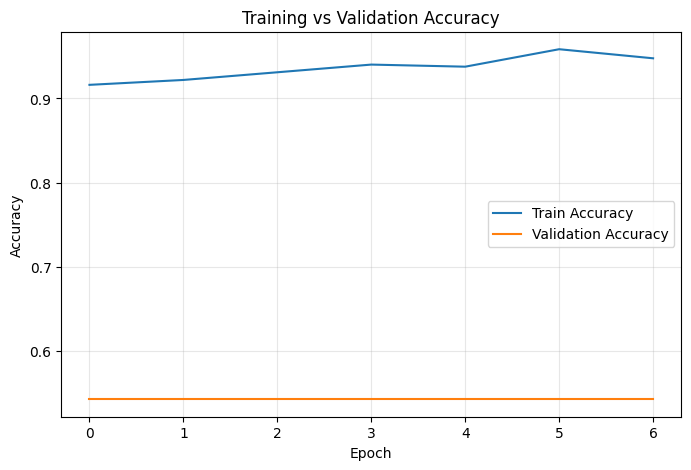

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

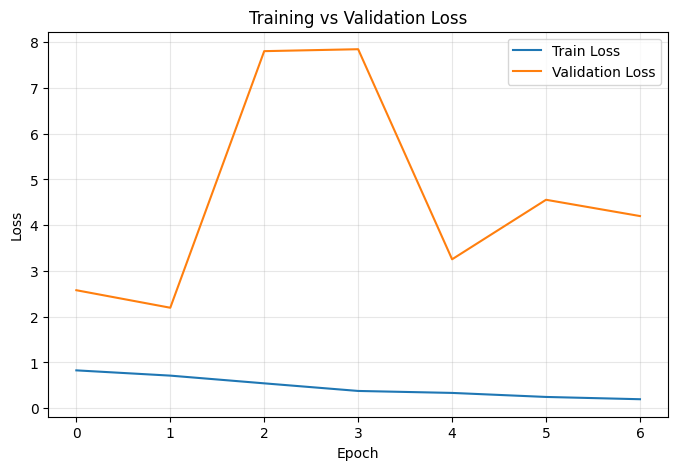

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 416ms/step - accuracy: 0.5444 - loss: 2.1485
Test Loss:     2.1485
Test Accuracy: 0.5444


In [23]:
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 548ms/step
              precision    recall  f1-score   support

         Day       0.00      0.00      0.00       118
       Night       0.54      1.00      0.70       141

    accuracy                           0.54       259
   macro avg       0.27      0.50      0.35       259
weighted avg       0.30      0.54      0.38       259



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


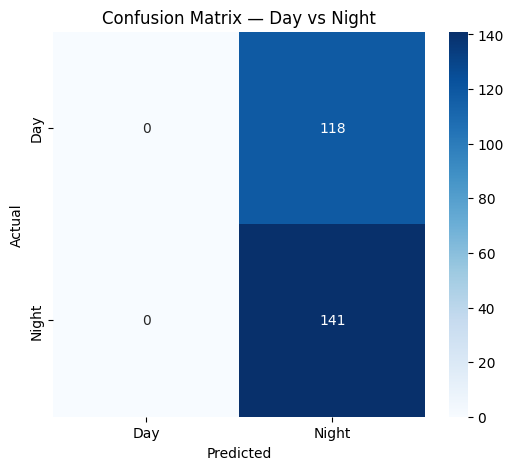

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Day vs Night")
plt.show()

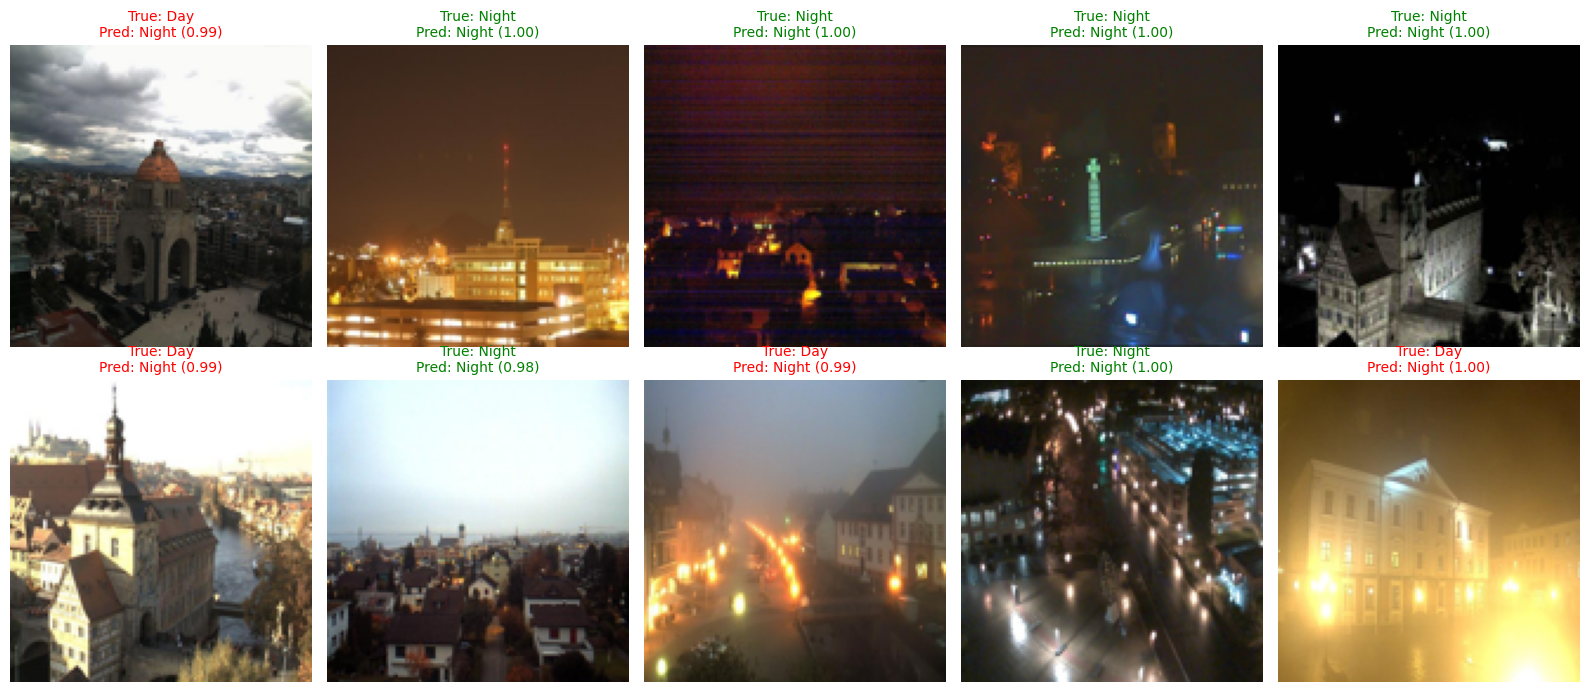

In [25]:
test_df_reset = test_df.reset_index(drop=True)
sample_idx = np.random.choice(len(test_df_reset), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, idx in zip(axes.flatten(), sample_idx):
    row = test_df_reset.iloc[idx]
    img = Image.open(row["filepath"]).resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img) / 255.0, axis=0)
    pred_prob = model.predict(arr, verbose=0)[0][0]
    pred_label = class_labels[int(pred_prob > 0.5)]
    true_label = row["label"]

    ax.imshow(img)
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})", color=color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

Upload an image to classify:


Saving 20151119_081621.jpg to 20151119_081621.jpg


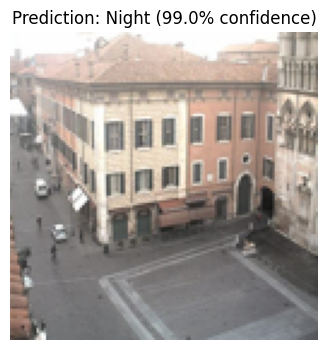

In [27]:
def predict_uploaded_image():
    print("Upload an image to classify:")
    uploaded_img = files.upload()

    for fname in uploaded_img.keys():
        img = Image.open(fname).convert("RGB").resize(IMG_SIZE)
        arr = np.expand_dims(np.array(img) / 255.0, axis=0)

        prob = model.predict(arr, verbose=0)[0][0]
        label = class_labels[int(prob > 0.5)]
        confidence = prob if label == class_labels[1] else 1 - prob

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Prediction: {label} ({confidence*100:.1f}% confidence)")
        plt.show()

predict_uploaded_image()